# Fetal Health Classification
## Multi-Class CTG Analysis: Normal | Suspect | Pathological


---
## Setup & Imports

In [1]:
import warnings, os, sys
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection        import (train_test_split, StratifiedKFold,
                                             GridSearchCV, cross_val_score,
                                             learning_curve)
from sklearn.preprocessing         import StandardScaler, LabelEncoder
# from sklearn.pipeline               import Pipeline
from sklearn.linear_model           import LogisticRegression
from sklearn.discriminant_analysis  import (LinearDiscriminantAnalysis,
                                             QuadraticDiscriminantAnalysis)
# from sklearn.neighbors              import KNeighborsClassifier
from sklearn.metrics                import (classification_report,
                                             confusion_matrix,
                                             ConfusionMatrixDisplay,
                                             f1_score, accuracy_score,
                                             precision_score, recall_score,
                                             roc_auc_score,
                                             balanced_accuracy_score,
                                             matthews_corrcoef,
                                             roc_curve, auc)
from sklearn.feature_selection      import (SelectKBest, f_classif,
                                             mutual_info_classif, RFE,
                                             SelectFromModel)
# from sklearn.inspection             import permutation_importance
from sklearn.decomposition          import PCA
from sklearn.utils.class_weight     import compute_class_weight

# ── Imbalanced-learn ──────────────────────────────────────────────────────────
from imblearn.over_sampling         import SMOTE, ADASYN
# from imblearn.combine               import SMOTETomek
# from imblearn.pipeline              import Pipeline as ImbPipeline


SEED = 42
np.random.seed(SEED)

# ── Styling ───────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

CLASS_NAMES  = ['Normal', 'Suspect', 'Pathological']
PALETTE      = {'Normal': '#2196F3', 'Suspect': '#FF9800', 'Pathological': '#F44336'}
CLF_COLORS   = ['#3F51B5', '#4CAF50', '#FF5722', '#9C27B0']   # LR, LDA

print('✅  All imports successful')
print(f'   NumPy {np.__version__}  |  pandas {pd.__version__}')

✅  All imports successful
   NumPy 2.4.4  |  pandas 3.0.1


---
## Data Loading & EDA

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

def load_fetal_health_data(path: str = 'datasets/fetal_health.csv') -> pd.DataFrame:
    """
    Load the Fetal Health dataset.
    """
    if os.path.exists(path):
        df = pd.read_csv(path)
    else:
        raise FileNotFoundError("Dataset file not found.")
    
    return df


def basic_eda(df: pd.DataFrame) -> None:
    """Print a quick EDA summary."""
    print('─' * 60)
    print(f'Shape          : {df.shape}')
    print(f'Missing values : {df.isnull().sum().sum()}')
    print(f'Duplicates     : {df.duplicated().sum()}')
    print('\nTarget distribution:')
    vc = df['fetal_health'].value_counts().sort_index()
    for k, v in vc.items():
        label = CLASS_NAMES[int(k) - 1]
        print(f'  Class {int(k)} ({label:<13}) → {v:>5}  ({v/len(df)*100:.1f}%)')
    print('─' * 60)


df_raw = load_fetal_health_data()
basic_eda(df_raw)
df_raw.head(3)

────────────────────────────────────────────────────────────
Shape          : (2126, 22)
Missing values : 0
Duplicates     : 13

Target distribution:
  Class 1 (Normal       ) →  1655  (77.8%)
  Class 2 (Suspect      ) →   295  (13.9%)
  Class 3 (Pathological ) →   176  (8.3%)
────────────────────────────────────────────────────────────


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0


In [3]:
# ── Describe numeric stats ─────────────────────────────────────────────────
df_raw.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.000000,133.303857,9.840844,106.000000,126.000000,133.000000,140.000000,160.000000
accelerations,2126.000000,0.003178,0.003866,0.000000,0.000000,0.002000,0.006000,0.019000
fetal_movement,2126.000000,0.009481,0.046666,0.000000,0.000000,0.000000,0.003000,0.481000
uterine_contractions,2126.000000,0.004366,0.002946,0.000000,0.002000,0.004000,0.007000,0.015000
light_decelerations,2126.000000,0.001889,0.002960,0.000000,0.000000,0.000000,0.003000,0.015000
severe_decelerations,2126.000000,0.000003,0.000057,0.000000,0.000000,0.000000,0.000000,0.001000
prolongued_decelerations,2126.000000,0.000159,0.000590,0.000000,0.000000,0.000000,0.000000,0.005000
abnormal_short_term_variability,2126.000000,46.990122,17.192814,12.000000,32.000000,49.000000,61.000000,87.000000
mean_value_of_short_term_variability,2126.000000,1.332785,0.883241,0.200000,0.700000,1.200000,1.700000,7.000000
percentage_of_time_with_abnormal_long_term_variability,2126.000000,9.846660,18.396880,0.000000,0.000000,0.000000,11.000000,91.000000


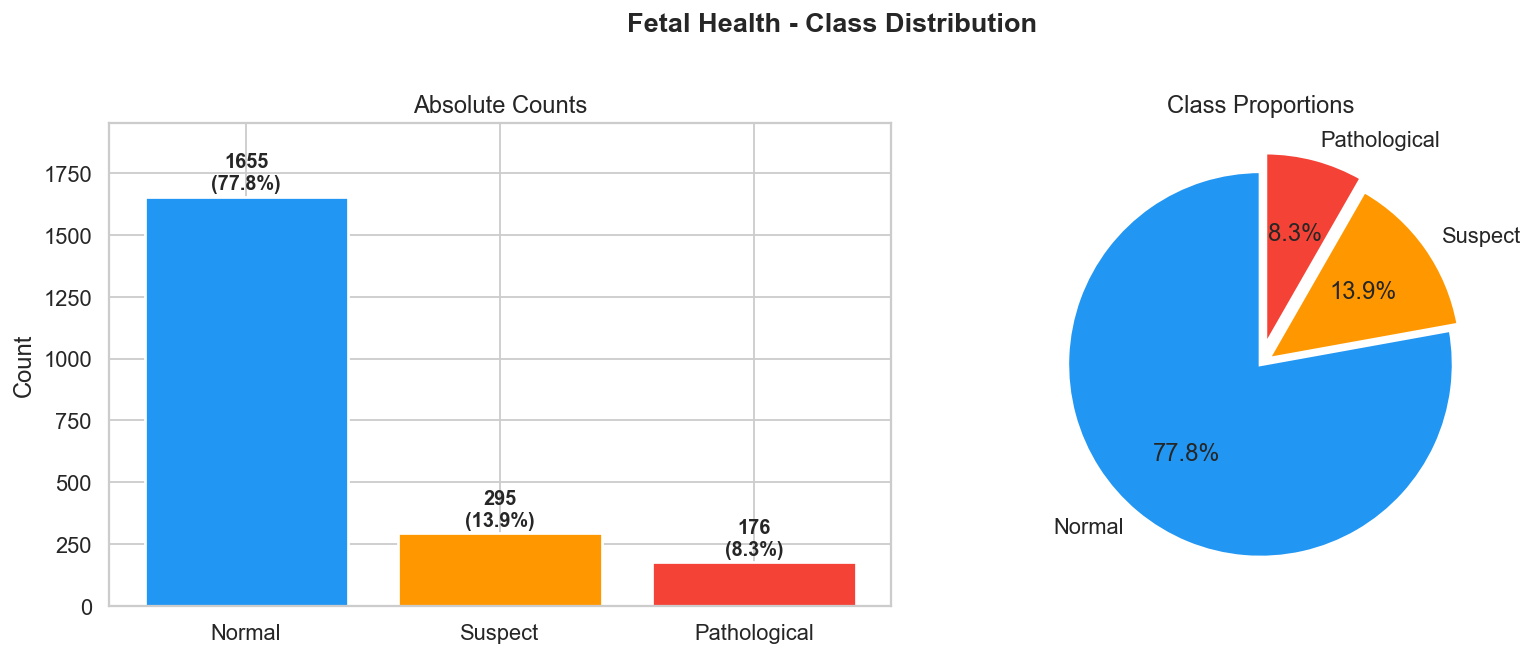

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  EDA VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════

def plot_class_distribution(df: pd.DataFrame) -> None:
    """Bar + pie chart of class imbalance."""
    vc  = df['fetal_health'].value_counts().sort_index()
    colors = list(PALETTE.values())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Fetal Health - Class Distribution', fontsize=15, fontweight='bold', y=1.01)

    # Bar
    bars = axes[0].bar(CLASS_NAMES, vc.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vc.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 12,
                     f'{val}\n({val/len(df)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Absolute Counts')
    axes[0].set_ylim(0, vc.max() * 1.18)

    # Pie
    axes[1].pie(vc.values, labels=CLASS_NAMES, colors=colors, autopct='%1.1f%%',
                startangle=90, explode=[0, 0.05, 0.10],
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('Class Proportions')

    plt.tight_layout()
    # plt.savefig('eda_class_distribution.png', bbox_inches='tight')
    plt.show()


plot_class_distribution(df_raw)

In [ ]:
# def plot_feature_distributions(df: pd.DataFrame, n_cols: int = 4) -> None:
#     """KDE plots for every feature, coloured by class."""
#     features = [c for c in df.columns if c != 'fetal_health']
#     n_rows   = int(np.ceil(len(features) / n_cols))
#     df_plot  = df.copy()
#     df_plot['label'] = df_plot['fetal_health'].map(
#         {1: 'Normal', 2: 'Suspect', 3: 'Pathological'})

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 2.8))
#     axes = axes.flatten()

#     for idx, feat in enumerate(features):
#         ax = axes[idx]
#         for cls in CLASS_NAMES:
#             subset = df_plot[df_plot['label'] == cls][feat].dropna()
#             if subset.nunique() < 2 or np.isclose(subset.std(), 0):
#                 ax.hist(subset, bins=8, alpha=0.35, density=True,
#                         label=f'{cls} (hist)', color=PALETTE[cls],
#                         edgecolor='k', linewidth=0.5)
#             else:
#                 try:
#                     subset.plot.kde(ax=ax, label=cls, color=PALETTE[cls], linewidth=1.8)
#                 except np.linalg.LinAlgError:
#                     ax.hist(subset, bins=8, alpha=0.35, density=True,
#                             label=f'{cls} (hist)', color=PALETTE[cls],
#                             edgecolor='k', linewidth=0.5)
#         ax.set_title(feat, fontsize=8, pad=3)
#         ax.set_xlabel('')
#         ax.tick_params(labelsize=7)
#         ax.legend(fontsize=6)

#     for j in range(idx + 1, len(axes)):
#         axes[j].set_visible(False)

#     fig.suptitle('Feature KDE Distributions by Fetal Health Class',
#                  fontsize=14, fontweight='bold', y=1.005)
#     plt.tight_layout()
#     # plt.savefig('eda_feature_kde.png', bbox_inches='tight')
#     plt.show()


# plot_feature_distributions(df_raw)

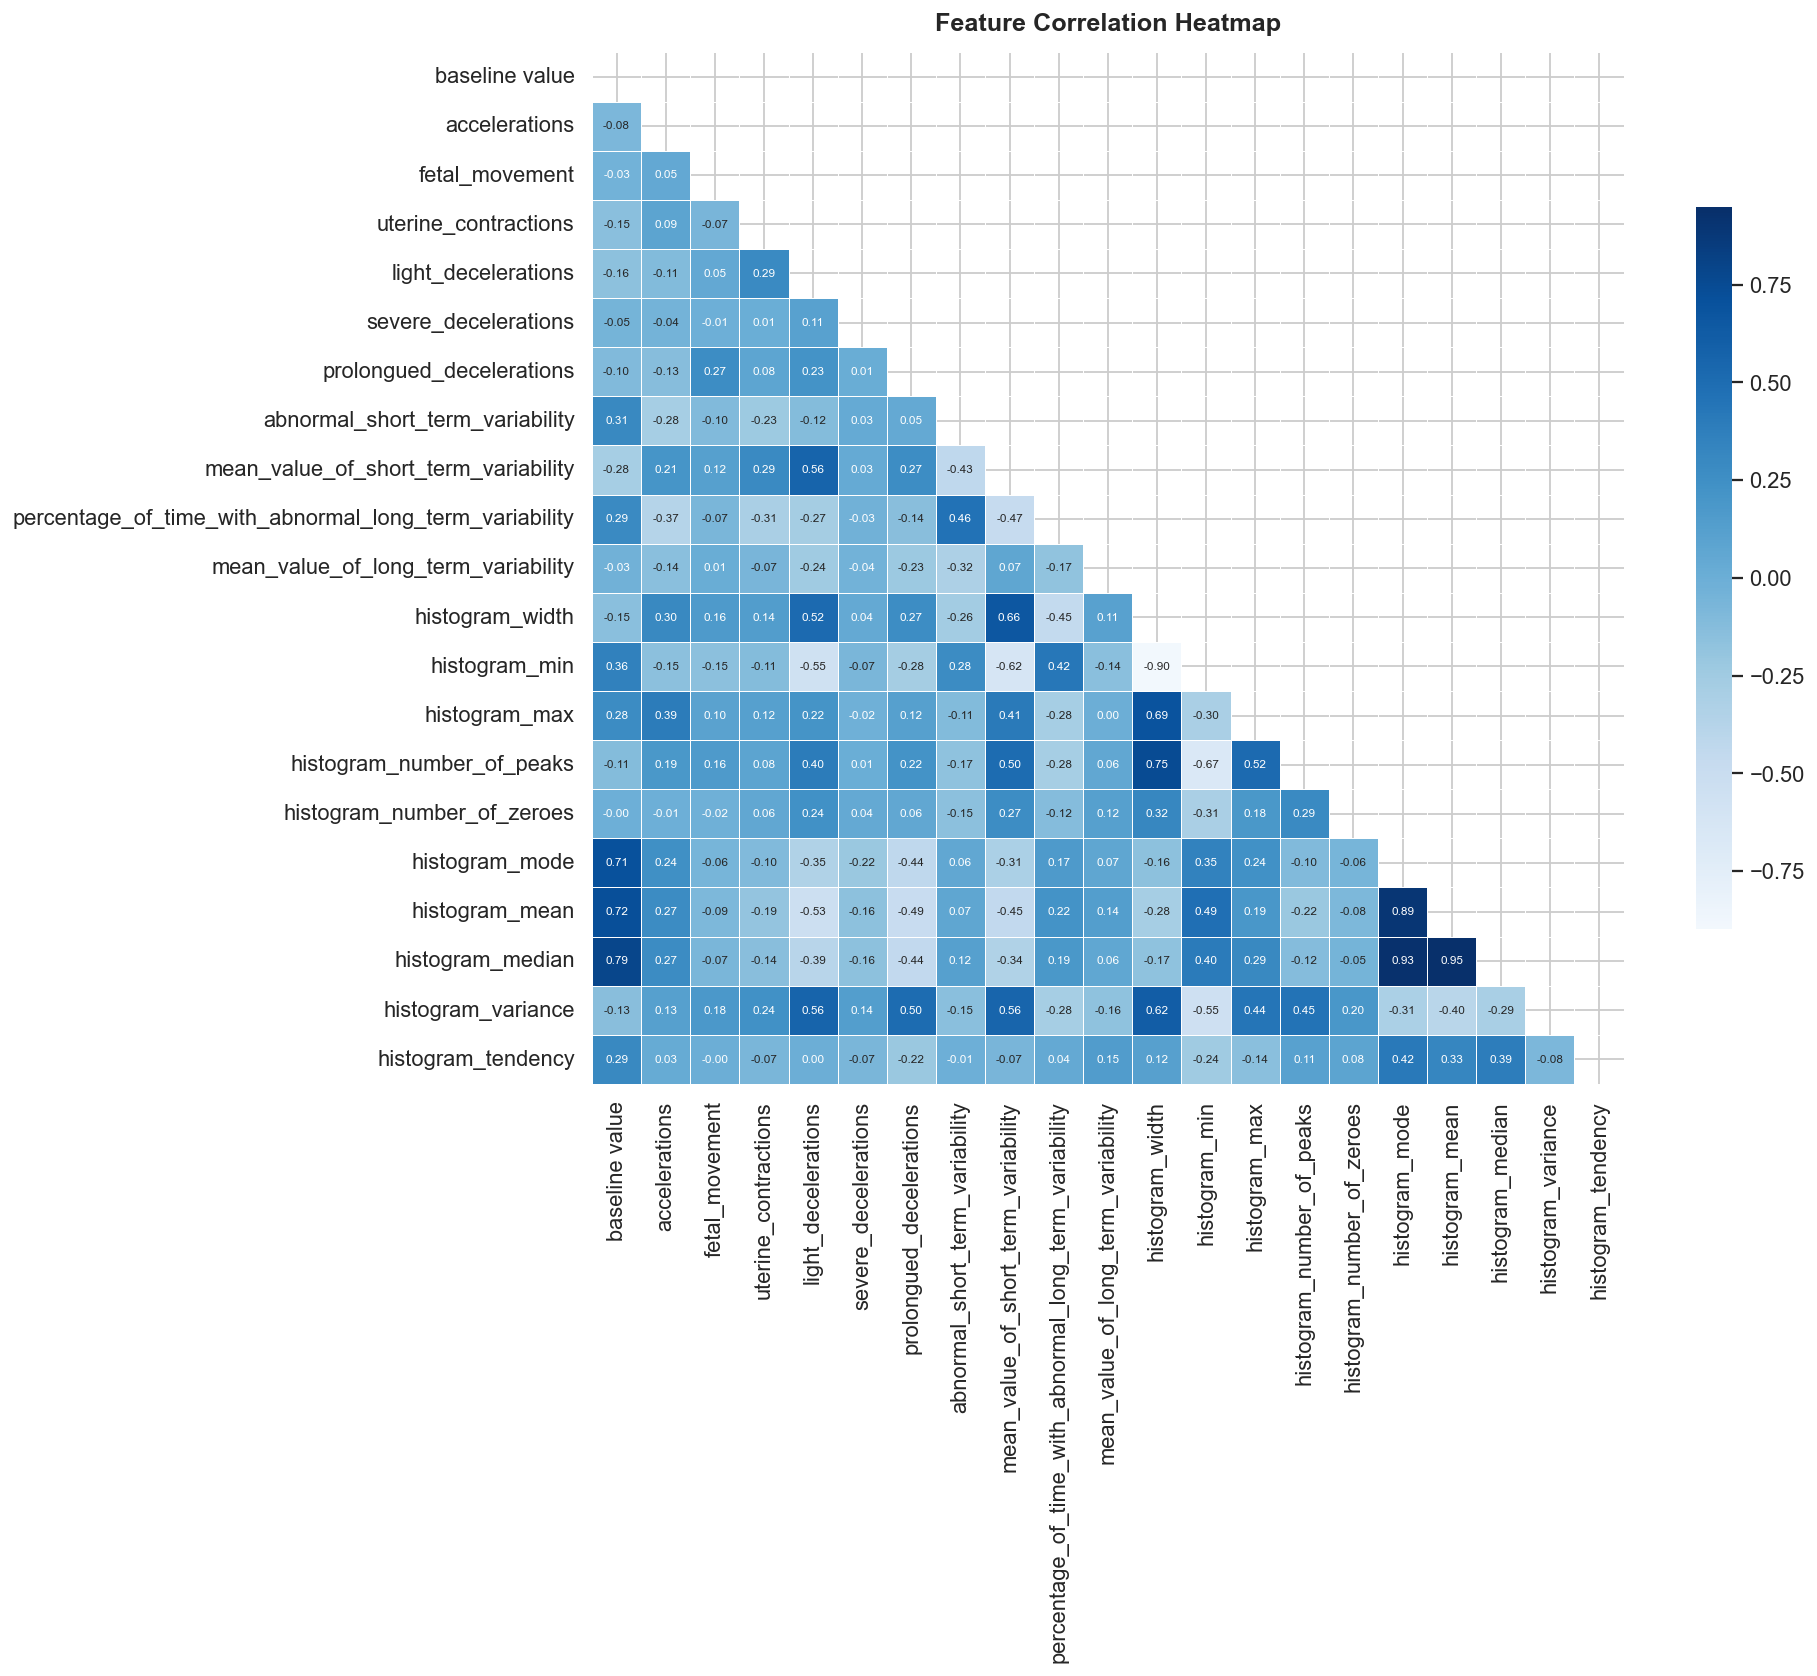

In [8]:
def plot_correlation_heatmap(df: pd.DataFrame) -> None:
    """Full correlation matrix of all features."""
    corr = df.drop(columns=['fetal_health']).corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(16, 13))
    sns.heatmap(corr, mask=mask, cmap='Blues', center=0,
                annot=True, fmt='.2f', annot_kws={'size': 6.5},
                linewidths=.3, ax=ax, square=True,
                cbar_kws={'shrink': .7})
    ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    # plt.savefig('eda_correlation.png', bbox_inches='tight')
    plt.show()


plot_correlation_heatmap(df_raw)

In [ ]:
def plot_boxplots_by_class(df: pd.DataFrame, top_n: int = 12) -> None:
    """Boxplots for the top N most discriminative features."""
    # from sklearn.preprocessing import LabelEncodertt
    feats = [c for c in df.columns if c != 'fetal_health']
    X_tmp = df[feats].values
    y_tmp = df['fetal_health'].values

    scores, _ = f_classif(X_tmp, y_tmp)
    top_feats  = [feats[i] for i in np.argsort(scores)[::-1][:top_n]]

    df_plot = df[top_feats + ['fetal_health']].copy()
    df_plot['label'] = df_plot['fetal_health'].map(
        {1: 'Normal', 2: 'Suspect', 3: 'Pathological'})

    n_cols = 4
    n_rows = int(np.ceil(top_n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()

    for idx, feat in enumerate(top_feats):
        ax = axes[idx]
        sns.boxplot(data=df_plot, x='label', y=feat, ax=ax,
                    palette=PALETTE, order=CLASS_NAMES,
                    linewidth=1.2, fliersize=2)
        ax.set_title(feat, fontsize=9, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(labelsize=8)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Top {top_n} Discriminative Features - Boxplot by Class',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    # plt.savefig('eda_boxplots.png', bbox_inches='tight')
    plt.show()


plot_boxplots_by_class(df_raw)

---
## Preprocessing & Feature Selection

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicates removed: {before - len(df)}  →  {len(df)} rows remain')
    return df


def encode_target(df: pd.DataFrame,
                  target_col: str = 'fetal_health') -> tuple[pd.DataFrame, dict]:
    """Convert 1/2/3 labels to 0/1/2 and return a mapping dict."""
    mapping = {1.0: 0, 2.0: 1, 3.0: 2}
    df      = df.copy()
    df[target_col] = df[target_col].map(mapping).astype(int)
    return df, mapping


def split_features_target(df: pd.DataFrame,
                           target_col: str = 'fetal_health') -> tuple:
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y


def train_test_stratified(X, y,
                           test_size: float = 0.20,
                           seed: int = SEED) -> tuple:
    return train_test_split(X, y,
                            test_size=test_size,
                            stratify=y,
                            random_state=seed)


# ── Run preprocessing pipeline ────────────────────────────────────────────────
df_clean          = remove_duplicates(df_raw)
df_encoded, label_map = encode_target(df_clean)
X_all, y_all      = split_features_target(df_encoded)
X_train_raw, X_test_raw, y_train, y_test = train_test_stratified(X_all, y_all)

print(f'\nTrain size: {X_train_raw.shape}  |  Test size: {X_test_raw.shape}')
print('Train class distribution:', dict(y_train.value_counts().sort_index()))
print('Test  class distribution:', dict(y_test.value_counts().sort_index()))

Duplicates removed: 13  →  2113 rows remain

Train size: (1690, 21)  |  Test size: (423, 21)
Train class distribution: {0: np.int64(1316), 1: np.int64(234), 2: np.int64(140)}
Test  class distribution: {0: np.int64(330), 1: np.int64(58), 2: np.int64(35)}


---
## Class Imbalance Handling

Class weights: {'Normal': '0.428', 'Suspect': '2.407', 'Pathological': '4.024'}


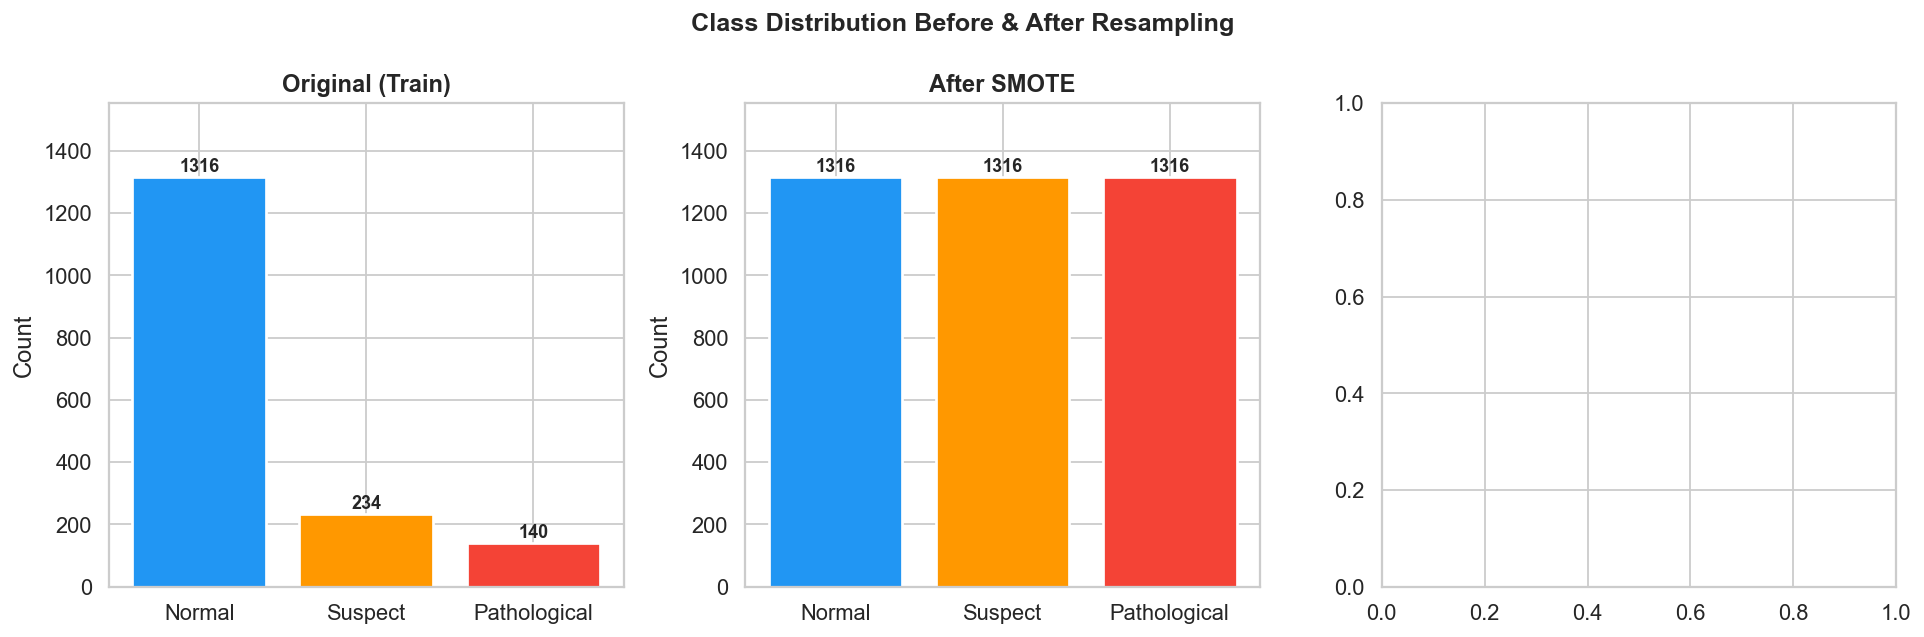

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  CLASS IMBALANCE STRATEGIES
# ══════════════════════════════════════════════════════════════════════════════

def apply_smote(X_train: pd.DataFrame,
                y_train: pd.Series,
                seed: int = SEED) -> tuple:
    """Basic SMOTE oversampling."""
    sm = SMOTE(random_state=seed, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    return X_res, y_res


# def apply_smote_tomek(X_train: pd.DataFrame,
#                       y_train: pd.Series,
#                       seed: int = SEED) -> tuple:
#     """SMOTETomek: oversample minority + remove Tomek links."""
#     smt = SMOTETomek(random_state=seed)
#     X_res, y_res = smt.fit_resample(X_train, y_train)
#     return X_res, y_res


def compute_class_weights(y: pd.Series) -> dict:
    """Compute balanced class weights for cost-sensitive classifiers."""
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes, weights))


def plot_resampling_comparison(y_orig: pd.Series,
                                y_smote: np.ndarray) -> None:
    """Bar comparison of class distribution across sampling strategies."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles    = ['Original (Train)', 'After SMOTE', 'After SMOTE-Tomek']
    y_sets    = [y_orig, y_smote]

    for ax, title, y_s in zip(axes, titles, y_sets):
        vc = pd.Series(y_s).value_counts().sort_index()
        bars = ax.bar(CLASS_NAMES, vc.values,
                      color=list(PALETTE.values()),
                      edgecolor='white', linewidth=1.5)
        for bar, val in zip(bars, vc.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 5,
                    str(val), ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel('Count')
        ax.set_ylim(0, max(vc.values) * 1.18)

    fig.suptitle('Class Distribution Before & After Resampling',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    # plt.savefig('resampling_comparison.png', bbox_inches='tight')
    plt.show()


# ── Apply both strategies ─────────────────────────────────────────────────────
X_train_smote,   y_train_smote   = apply_smote(X_train_raw, y_train)
# X_train_smt,     y_train_smt     = apply_smote_tomek(X_train_fs, y_train)
class_weights                    = compute_class_weights(y_train)

print('Class weights:', {CLASS_NAMES[k]: f'{v:.3f}' for k, v in class_weights.items()})
plot_resampling_comparison(y_train, y_train_smote)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  FEATURE SELECTION
# ══════════════════════════════════════════════════════════════════════════════

selected_features = []

ANOVA selected  : 15 features
MI selected     : 15 features
Union selected  : 18 features

Selected: ['abnormal_short_term_variability', 'accelerations', 'baseline value', 'histogram_max', 'histogram_mean', 'histogram_median', 'histogram_min', 'histogram_mode', 'histogram_number_of_peaks', 'histogram_tendency', 'histogram_variance', 'histogram_width', 'light_decelerations', 'mean_value_of_long_term_variability', 'mean_value_of_short_term_variability', 'percentage_of_time_with_abnormal_long_term_variability', 'prolongued_decelerations', 'uterine_contractions']


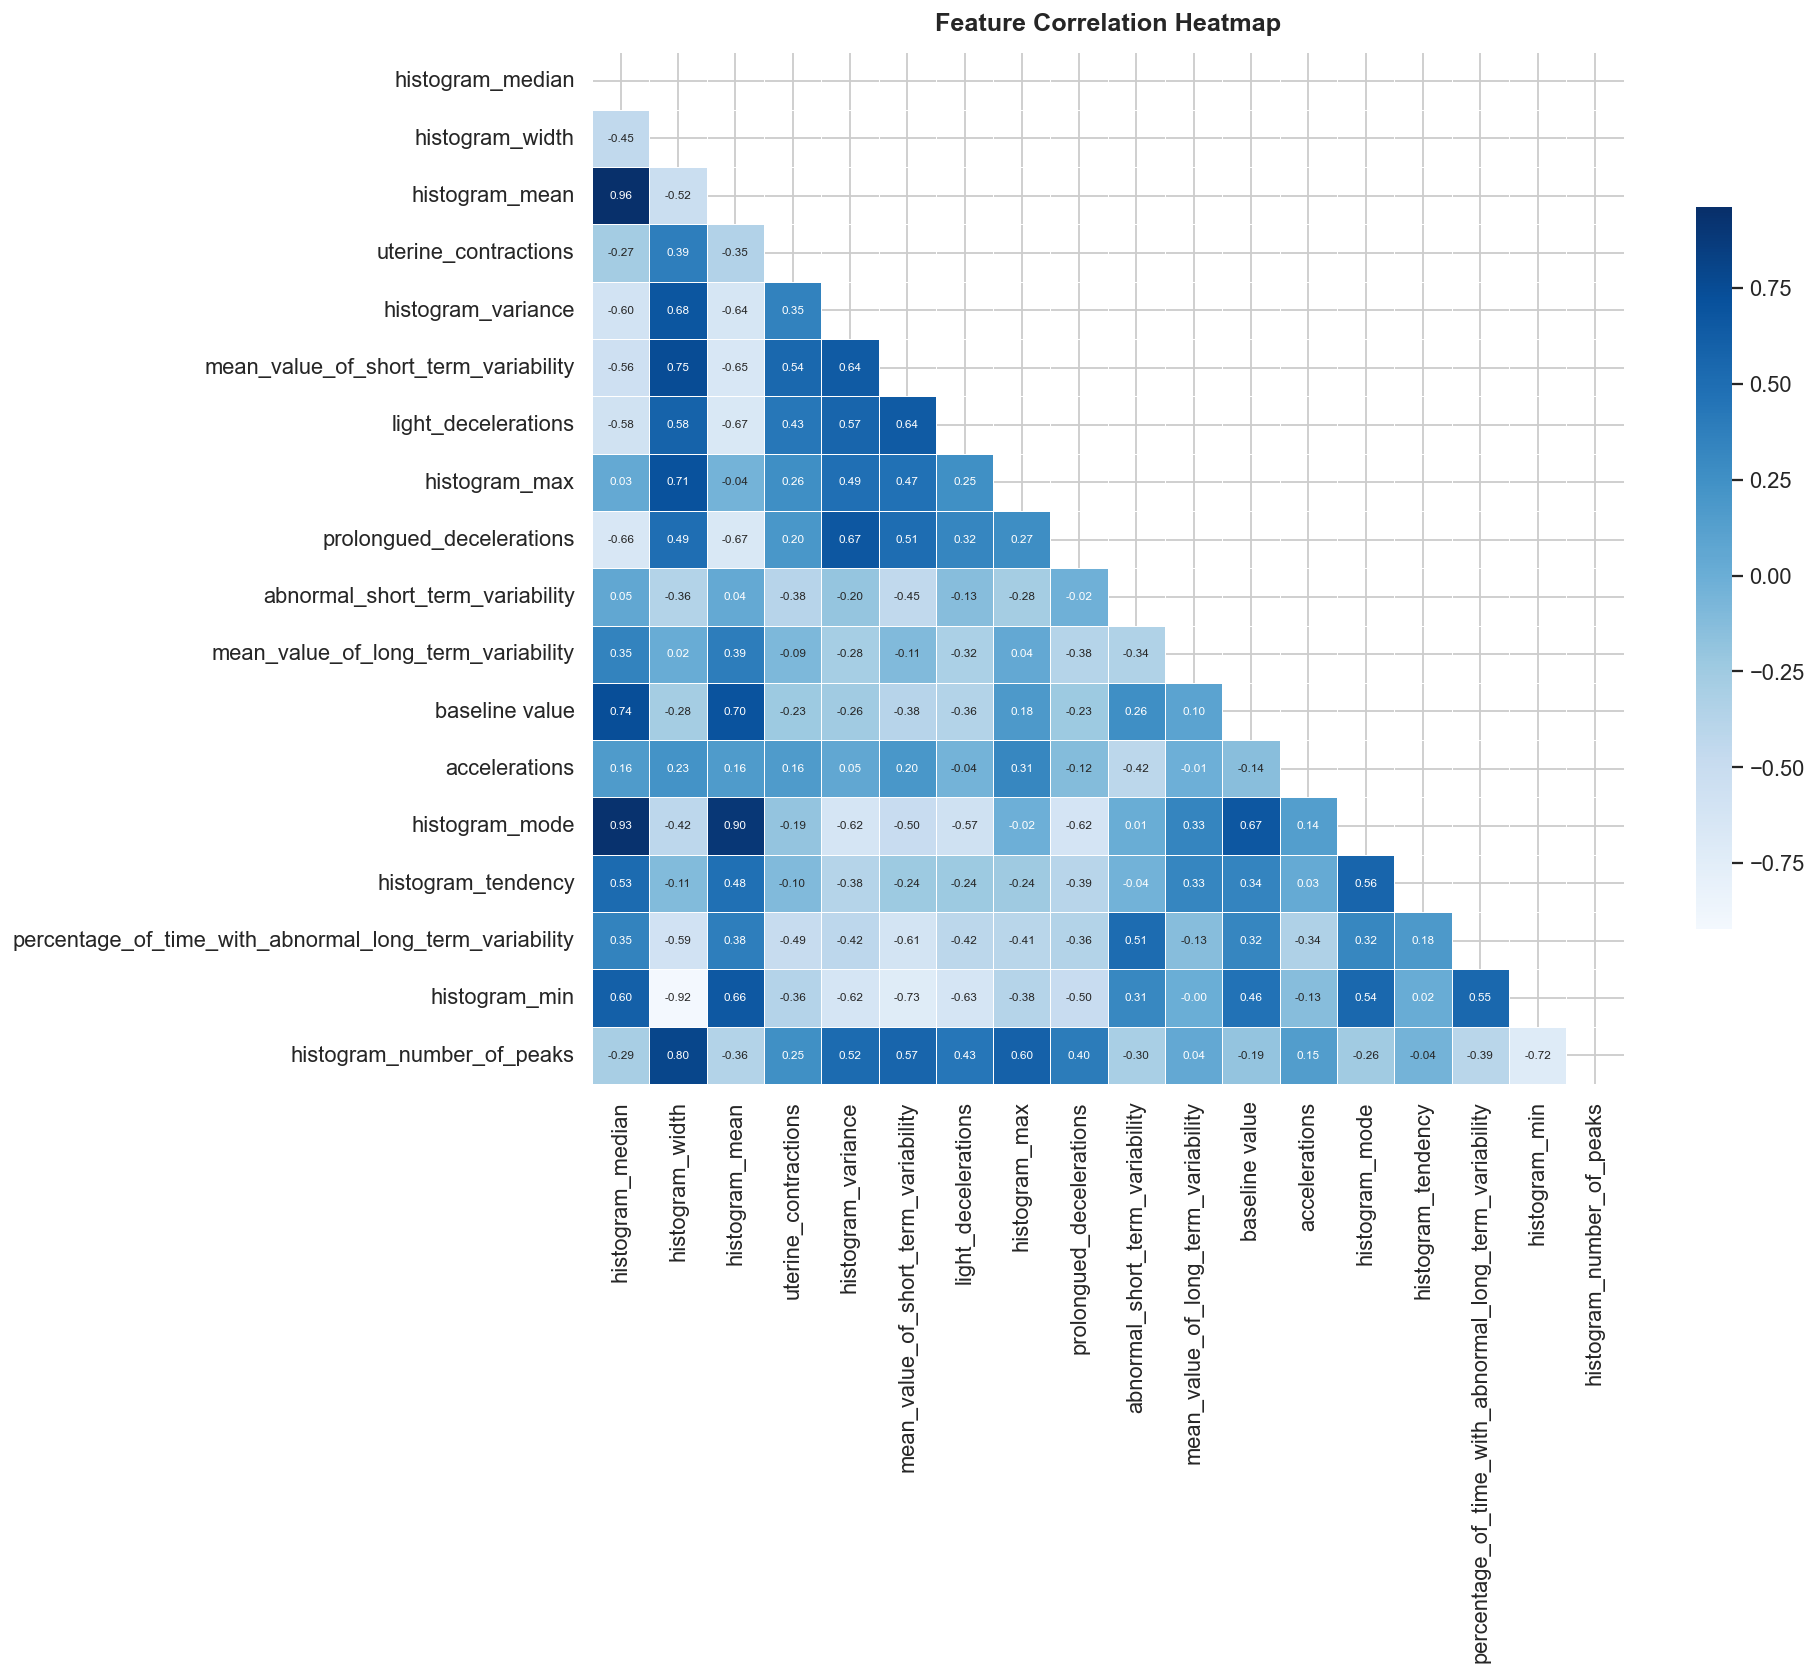

In [17]:
# plot correlation heatmap of selected features
plot_correlation_heatmap(X_train_smote[selected_features].assign(fetal_health=y_train_smote))

In [9]:
selected_features

['histogram_width',
 'histogram_median',
 'histogram_mean',
 'uterine_contractions',
 'histogram_variance',
 'mean_value_of_short_term_variability',
 'light_decelerations',
 'histogram_max',
 'prolongued_decelerations',
 'abnormal_short_term_variability',
 'mean_value_of_long_term_variability',
 'baseline value',
 'accelerations',
 'histogram_mode',
 'percentage_of_time_with_abnormal_long_term_variability',
 'histogram_min']

In [10]:
# ── Apply feature selection ────────────────────────────────────────────────────
X_train_fs = X_train_scaled[selected_features]
X_test_fs  = X_test_scaled[selected_features]

print(f'Training features shape : {X_train_fs.shape}')
print(f'Test features shape     : {X_test_fs.shape}')

Training features shape : (1690, 16)
Test features shape     : (423, 16)


---
## Hyperparameter Optimisation

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  HYPERPARAMETER GRIDS & OPTIMISATION
# ══════════════════════════════════════════════════════════════════════════════

CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING     = 'f1_macro'

# ── Param grids ───────────────────────────────────────────────────────────────
PARAM_GRIDS = {
    'Logistic Regression': {
        'C'            : [0.001, 0.01, 0.1, 1, 10, 100],
        'solver'       : ['lbfgs', 'saga'],
        # 'multi_class'  : ['ovr', 'multinomial'],
        'l1_ratio'    : [None, 0.5, 0.7, 0.9],  # Only for 'saga' solver
        'max_iter'     : [1000, 2000, 5000],
        'class_weight' : ['balanced', None],
        
    },
    'LDA': {
        'solver'       : ['svd', 'lsqr', 'eigen'],
        'shrinkage'    : [None, 'auto', 0.1, 0.5, 0.9]
    }
}

# ── Base estimators ───────────────────────────────────────────────────────────
BASE_ESTIMATORS = {
    'Logistic Regression' : LogisticRegression(random_state=SEED),
    'LDA'                 : LinearDiscriminantAnalysis(),
}


def run_grid_search(estimators: dict,
                    param_grids: dict,
                    X_train: np.ndarray,
                    y_train: np.ndarray,
                    cv, scoring: str = 'f1_macro') -> dict:
    """
    Run GridSearchCV for each classifier.
    Returns a dict: {name: {best_estimator, best_params, best_score, cv_results}}
    """
    results = {}
    for name, estimator in estimators.items():
        print(f'  Tuning {name}…', end=' ', flush=True)
        grid = GridSearchCV(
            estimator  = estimator,
            param_grid = param_grids[name],
            cv         = cv,
            scoring    = scoring,
            n_jobs     = -1,
            refit      = True
        )
        grid.fit(X_train, y_train)
        results[name] = {
            'best_estimator': grid.best_estimator_,
            'best_params'   : grid.best_params_,
            'best_score'    : grid.best_score_,
            'cv_results'    : pd.DataFrame(grid.cv_results_)
        }
        print(f'✓  best CV F1-macro = {grid.best_score_:.4f}')
    return results


# ── Run on SMOTETomek-resampled data (best strategy) ─────────────────────────
print('=== GridSearchCV on SMOTE-resampled training data ===')
gs_results = run_grid_search(
    BASE_ESTIMATORS, PARAM_GRIDS,
    X_train_smote, y_train_smote,
    CV_STRATEGY, SCORING)

print('\n=== Best Hyperparameters ===')
for name, res in gs_results.items():
    print(f'\n  {name}: {res["best_params"]}')
    print(f'    CV F1-macro: {res["best_score"]:.4f}')

In [ ]:
# def plot_cv_score_distributions(gs_results: dict) -> None:
#     """Violin plots of 5-fold CV score distributions per classifier."""
#     fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
#     fig.suptitle('Cross-Validation F1-Macro Score Distributions (Top-20 Parameter Combos)',
#                  fontsize=13, fontweight='bold')

#     for ax, (name, res), color in zip(axes, gs_results.items(), CLF_COLORS):
#         cv_df = res['cv_results'].sort_values('mean_test_score', ascending=False).head(20)
#         scores = cv_df[[f'split{i}_test_score' for i in range(5)]].values.flatten()
#         ax.violinplot([scores], positions=[0], showmedians=True,
#                        showextrema=True)
#         ax.scatter([0] * len(scores), scores, color=color,
#                    alpha=0.5, s=20, zorder=3)
#         ax.axhline(res['best_score'], color='red', linewidth=1.5,
#                    linestyle='--', label=f'Best: {res["best_score"]:.4f}')
#         ax.set_title(name, fontweight='bold')
#         ax.set_xticks([])
#         ax.legend(fontsize=8)
#     axes[0].set_ylabel('F1-Macro')
#     plt.tight_layout()
#     # plt.savefig('cv_distributions.png', bbox_inches='tight')
#     plt.show()


# plot_cv_score_distributions(gs_results)

---
## Model Training & Evaluation

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  EVALUATION UTILITIES
# ══════════════════════════════════════════════════════════════════════════════

def compute_all_metrics(y_true: np.ndarray,
                         y_pred: np.ndarray,
                         y_proba: np.ndarray = None,
                         class_names: list = CLASS_NAMES) -> dict:
    """Return a comprehensive metrics dict."""
    metrics = {
        'accuracy'        : accuracy_score(y_true, y_pred),
        'balanced_acc'    : balanced_accuracy_score(y_true, y_pred),
        'f1_macro'        : f1_score(y_true, y_pred, average='macro'),
        'f1_weighted'     : f1_score(y_true, y_pred, average='weighted'),
        'precision_macro' : precision_score(y_true, y_pred, average='macro'),
        'recall_macro'    : recall_score(y_true, y_pred, average='macro'),
        'mcc'             : matthews_corrcoef(y_true, y_pred),
    }
    # Per-class F1
    f1_per = f1_score(y_true, y_pred, average=None)
    for cls, f1 in zip(class_names, f1_per):
        metrics[f'f1_{cls.lower()}'] = f1
    # ROC-AUC (requires probabilities)
    if y_proba is not None:
        metrics['roc_auc_ovr'] = roc_auc_score(
            y_true, y_proba, multi_class='ovr', average='macro')
    return metrics


def evaluate_all_classifiers(gs_results: dict,
                              X_train, y_train,
                              X_test,  y_test) -> pd.DataFrame:
    """Fit best estimators on full training set and evaluate on test set."""
    rows = []
    for name, res in gs_results.items():
        clf = res['best_estimator']
        clf.fit(X_train, y_train)
        y_pred  = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test) \
                  if hasattr(clf, 'predict_proba') else None
        mets = compute_all_metrics(y_test, y_pred, y_proba)
        mets['classifier'] = name
        rows.append(mets)
    df_metrics = pd.DataFrame(rows).set_index('classifier')
    return df_metrics


metrics_df = evaluate_all_classifiers(
    gs_results, X_train_smote, y_train_smote, X_test_fs, y_test)

print('\n=== TEST SET PERFORMANCE SUMMARY ===')
display_cols = ['accuracy', 'balanced_acc', 'f1_macro', 'f1_weighted',
                'f1_normal', 'f1_suspect', 'f1_pathological', 'mcc']
metrics_df[display_cols].style\
    .background_gradient(cmap='RdYlGn', axis=0)\
    .format('{:.4f}')

In [ ]:
# Full sklearn classification report for each classifier
def print_classification_reports(gs_results: dict,
                                   X_train, y_train,
                                   X_test,  y_test) -> None:
    for name, res in gs_results.items():
        clf = res['best_estimator']
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        print('=' * 55)
        print(f'  {name}')
        print('=' * 55)
        print(classification_report(y_test, y_pred,
                                     target_names=CLASS_NAMES))


print_classification_reports(
    gs_results, X_train_smote, y_train_smote, X_test_fs, y_test)

---
## Visualisations

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFUSION MATRICES – All 2 classifiers side by side
# ══════════════════════════════════════════════════════════════════════════════

def plot_all_confusion_matrices(gs_results: dict,
                                 X_train, y_train,
                                 X_test,  y_test,
                                 class_names: list = CLASS_NAMES) -> None:
    """2x2 grid of confusion matrices (counts + normalised)."""
    fig, axes = plt.subplots(2, 4, figsize=(22, 11))
    fig.suptitle('Confusion Matrices - All Classifiers',
                 fontsize=15, fontweight='bold', y=1.01)

    cmaps_raw  = ['Blues',   'Greens',  'Oranges', 'Purples']
    cmaps_norm = ['YlOrRd',  'YlGn',    'YlOrBr',  'PuRd']

    for col, (name, res) in enumerate(gs_results.items()):
        clf = res['best_estimator']
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        cm      = confusion_matrix(y_test, y_pred)
        cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

        for row, (mat, cmap, title_sfx) in enumerate(
                [(cm, cmaps_raw[col], 'Counts'),
                 (cm_norm, cmaps_norm[col], 'Normalised')]):
            ax = axes[row][col]
            fmt = 'd' if row == 0 else '.2f'
            sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap,
                        xticklabels=class_names, yticklabels=class_names,
                        ax=ax, linewidths=0.5,
                        cbar_kws={'shrink': .75})
            ax.set_title(f'{name}\n({title_sfx})', fontsize=10, fontweight='bold')
            ax.set_ylabel('Actual'  if col == 0 else '')
            ax.set_xlabel('Predicted')

    plt.tight_layout()
    # plt.savefig('confusion_matrices_all.png', bbox_inches='tight')
    plt.show()


plot_all_confusion_matrices(
    gs_results, X_train_smote, y_train_smote, X_test_fs, y_test)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  ROC CURVES (one-vs-rest, macro)
# ══════════════════════════════════════════════════════════════════════════════

def plot_roc_curves(gs_results: dict,
                    X_train, y_train,
                    X_test,  y_test,
                    class_names: list = CLASS_NAMES) -> None:
    """OVR ROC curves per class per classifier in a 4×3 grid."""
    n_clf   = len(gs_results)
    n_cls   = len(class_names)
    fig, axes = plt.subplots(n_clf, n_cls,
                              figsize=(5 * n_cls, 4.5 * n_clf))
    fig.suptitle('ROC Curves - One vs Rest per Classifier',
                 fontsize=14, fontweight='bold', y=1.01)

    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y_test, classes=[0, 1, 2])

    for row, (name, res) in enumerate(gs_results.items()):
        clf = res['best_estimator']
        clf.fit(X_train, y_train)
        if not hasattr(clf, 'predict_proba'):
            for c in range(n_cls):
                axes[row][c].text(0.5, 0.5, 'No predict_proba',
                                  ha='center', va='center')
            continue
        y_score = clf.predict_proba(X_test)

        for col, cls_name in enumerate(class_names):
            ax = axes[row][col]
            fpr, tpr, _ = roc_curve(y_bin[:, col], y_score[:, col])
            roc_auc_val = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=CLF_COLORS[row], lw=2,
                    label=f'AUC = {roc_auc_val:.3f}')
            ax.plot([0, 1], [0, 1], 'k--', lw=1)
            ax.fill_between(fpr, tpr, alpha=0.08, color=CLF_COLORS[row])
            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.02])
            ax.set_xlabel('FPR')
            ax.set_ylabel('TPR')
            ax.set_title(f'{name}\nClass: {cls_name}', fontsize=9, fontweight='bold')
            ax.legend(loc='lower right', fontsize=9)

    plt.tight_layout()
    # plt.savefig('roc_curves.png', bbox_inches='tight')
    plt.show()


plot_roc_curves(gs_results, X_train_smote, y_train_smote, X_test_fs, y_test)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  LEARNING CURVES
# ══════════════════════════════════════════════════════════════════════════════

def plot_learning_curves(gs_results: dict,
                          X_train, y_train,
                          cv, scoring: str = 'f1_macro') -> None:
    """Learning curves for all classifiers."""
    fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
    fig.suptitle('Learning Curves (F1-Macro vs Training Size)',
                 fontsize=14, fontweight='bold')

    for ax, (name, res), color in zip(axes, gs_results.items(), CLF_COLORS):
        clf = res['best_estimator']
        train_sizes, train_scores, val_scores = learning_curve(
            clf, X_train, y_train,
            cv=cv, scoring=scoring,
            train_sizes=np.linspace(0.1, 1.0, 8),
            n_jobs=-1)

        train_mean = train_scores.mean(axis=1)
        train_std  = train_scores.std(axis=1)
        val_mean   = val_scores.mean(axis=1)
        val_std    = val_scores.std(axis=1)

        ax.plot(train_sizes, train_mean, 'o-', color=color,  label='Train')
        ax.fill_between(train_sizes,
                        train_mean - train_std,
                        train_mean + train_std, alpha=0.15, color=color)
        ax.plot(train_sizes, val_mean, 's--', color='gray', label='Validation')
        ax.fill_between(train_sizes,
                        val_mean - val_std,
                        val_mean + val_std, alpha=0.10, color='gray')
        ax.set_title(name, fontweight='bold')
        ax.set_xlabel('Training Samples')
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.05)

    axes[0].set_ylabel('F1-Macro')
    plt.tight_layout()
    # plt.savefig('learning_curves.png', bbox_inches='tight')
    plt.show()


plot_learning_curves(gs_results, X_train_smote, y_train_smote, CV_STRATEGY)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  PCA DECISION BOUNDARY (2-D projection)
# ══════════════════════════════════════════════════════════════════════════════

def plot_decision_boundaries_pca(gs_results: dict,
                                  X_train, y_train,
                                  X_test,  y_test,
                                  class_names: list = CLASS_NAMES) -> None:
    """Project to 2 PCA dims and plot decision regions."""
    pca = PCA(n_components=2, random_state=SEED)
    X_tr2  = pca.fit_transform(X_train)
    X_te2  = pca.transform(X_test)

    h    = 0.06
    cmap = plt.cm.get_cmap('coolwarm', 3)
    x_min, x_max = X_tr2[:, 0].min() - 1, X_tr2[:, 0].max() + 1
    y_min, y_max = X_tr2[:, 1].min() - 1, X_tr2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle('Decision Boundaries in 2-D PCA Space',
                 fontsize=14, fontweight='bold')

    marker_map = {0: 'o', 1: 's', 2: '^'}

    for ax, (name, res) in zip(axes, gs_results.items()):
        clf2 = res['best_estimator'].__class__(**res['best_params'])
        clf2.fit(X_tr2, y_train)
        Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap)
        ax.contour(xx, yy, Z, colors='white', linewidths=0.5, alpha=0.4)

        for cls_idx, cls_name in enumerate(class_names):
            mask = y_test == cls_idx
            ax.scatter(X_te2[mask, 0], X_te2[mask, 1],
                       c=list(PALETTE.values())[cls_idx],
                       marker=marker_map[cls_idx],
                       label=cls_name, s=18, edgecolors='k',
                       linewidths=0.3, alpha=0.8)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(name, fontweight='bold')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.legend(fontsize=7, markerscale=1.2)

    plt.tight_layout()
    # plt.savefig('decision_boundaries.png', bbox_inches='tight')
    plt.show()


plot_decision_boundaries_pca(
    gs_results, X_train_smote, y_train_smote, X_test_fs, y_test)

In [ ]:
# # ══════════════════════════════════════════════════════════════════════════════
# #  PER-CLASS F1 RADAR CHART
# # ══════════════════════════════════════════════════════════════════════════════

# def plot_radar_chart(metrics_df: pd.DataFrame,
#                      class_names: list = CLASS_NAMES) -> None:
#     """Radar/spider chart of per-class F1 scores."""
#     metrics_cols = [f'f1_{c.lower()}' for c in class_names]
#     labels       = class_names + [class_names[0]]          # close polygon
#     angles       = np.linspace(0, 2 * np.pi, len(class_names),
#                                endpoint=False).tolist()
#     angles      += angles[:1]

#     fig, ax = plt.subplots(figsize=(8, 8),
#                             subplot_kw=dict(polar=True))
#     for clf_name, color in zip(metrics_df.index, CLF_COLORS):
#         values = metrics_df.loc[clf_name, metrics_cols].tolist()
#         values += values[:1]
#         ax.plot(angles, values, 'o-', linewidth=2.2,
#                 label=clf_name, color=color)
#         ax.fill(angles, values, alpha=0.08, color=color)

#     ax.set_thetagrids(np.degrees(angles[:-1]), labels=class_names, fontsize=12)
#     ax.set_ylim(0, 1)
#     ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
#     ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
#     ax.set_title('Per-Class F1 Score Radar Chart',
#                  fontsize=14, fontweight='bold', pad=20)
#     ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
#     plt.tight_layout()
#     # plt.savefig('radar_chart.png', bbox_inches='tight')
#     plt.show()


# plot_radar_chart(metrics_df)

In [ ]:
# # ══════════════════════════════════════════════════════════════════════════════
# #  K SENSITIVITY PLOT (KNN only)
# # ══════════════════════════════════════════════════════════════════════════════

# def plot_knn_k_sensitivity(X_train, y_train,
#                             X_test,  y_test,
#                             k_range: range = range(1, 31)) -> None:
#     """F1-macro vs K for KNN."""
#     f1s = []
#     for k in k_range:
#         knn = KNeighborsClassifier(n_neighbors=k)
#         knn.fit(X_train, y_train)
#         f1s.append(f1_score(y_test, knn.predict(X_test), average='macro'))

#     best_k  = k_range[int(np.argmax(f1s))]
#     best_f1 = max(f1s)

#     fig, ax = plt.subplots(figsize=(10, 5))
#     ax.plot(list(k_range), f1s, 'o-', color='#FF5722', linewidth=2)
#     ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5,
#                label=f'Best k={best_k}  F1={best_f1:.4f}')
#     ax.set_xlabel('Number of Neighbours (k)', fontsize=12)
#     ax.set_ylabel('F1-Macro (Test)', fontsize=12)
#     ax.set_title('KNN - F1-Macro Sensitivity to k', fontsize=13, fontweight='bold')
#     ax.legend(fontsize=11)
#     plt.tight_layout()
#     # plt.savefig('knn_k_sensitivity.png', bbox_inches='tight')
#     plt.show()


# plot_knn_k_sensitivity(X_train_smote, y_train_smote, X_test_fs, y_test)

---
## Final Comparison

In [ ]:
# # ══════════════════════════════════════════════════════════════════════════════
# #  GROUPED BAR – ALL METRICS SIDE BY SIDE
# # ══════════════════════════════════════════════════════════════════════════════

# def plot_metrics_comparison(metrics_df: pd.DataFrame) -> None:
#     """Grouped bar chart comparing all classifiers across key metrics."""
#     key_metrics = ['accuracy', 'balanced_acc', 'f1_macro', 'f1_weighted',
#                    'precision_macro', 'recall_macro', 'mcc']
#     available   = [m for m in key_metrics if m in metrics_df.columns]
#     plot_df     = metrics_df[available]

#     x   = np.arange(len(available))
#     w   = 0.18
#     fig, ax = plt.subplots(figsize=(16, 6))

#     for i, (clf_name, color) in enumerate(
#             zip(plot_df.index, CLF_COLORS)):
#         vals = plot_df.loc[clf_name, available].values
#         offset = (i - 1.5) * w
#         bars = ax.bar(x + offset, vals, width=w,
#                       label=clf_name, color=color,
#                       edgecolor='white', linewidth=0.7)
#         for bar, val in zip(bars, vals):
#             ax.text(bar.get_x() + bar.get_width()/2,
#                     bar.get_height() + 0.005,
#                     f'{val:.3f}', ha='center', va='bottom',
#                     fontsize=6.5, rotation=45)

#     ax.set_xticks(x)
#     ax.set_xticklabels([m.replace('_', ' ').title()
#                         for m in available], fontsize=10)
#     ax.set_ylim(0, 1.18)
#     ax.set_ylabel('Score')
#     ax.set_title('Classifier Comparison - All Metrics (Test Set)',
#                  fontsize=14, fontweight='bold')
#     ax.legend(fontsize=10)
#     ax.axhline(0.8, color='gray', linestyle=':', linewidth=1, alpha=0.5)
#     plt.tight_layout()
#     # plt.savefig('metrics_comparison.png', bbox_inches='tight')
#     plt.show()


# plot_metrics_comparison(metrics_df)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  HEATMAP – ALL METRICS SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════

def plot_summary_heatmap(metrics_df: pd.DataFrame) -> None:
    plot_cols = ['accuracy', 'balanced_acc', 'f1_macro', 'f1_weighted',
                 'f1_normal', 'f1_suspect', 'f1_pathological', 'mcc']
    available = [c for c in plot_cols if c in metrics_df.columns]
    data      = metrics_df[available].astype(float)

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(data, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, vmin=0.5, vmax=1.0,
                ax=ax, annot_kws={'size': 11, 'fontweight': 'bold'})
    ax.set_title('Performance Heatmap - All Classifiers x All Metrics',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xticklabels([c.replace('_', ' ').title() for c in available],
                       rotation=25, ha='right', fontsize=10)
    plt.tight_layout()
    # plt.savefig('summary_heatmap.png', bbox_inches='tight')
    plt.show()


plot_summary_heatmap(metrics_df)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  FINAL RANKING & WINNER DECLARATION
# ══════════════════════════════════════════════════════════════════════════════

def declare_winner(metrics_df: pd.DataFrame,
                   primary_metric: str = 'f1_macro') -> None:
    """Print ranked table and highlight the best classifier."""
    cols = ['accuracy', 'balanced_acc', 'f1_macro', 'f1_weighted',
            'f1_normal', 'f1_suspect', 'f1_pathological', 'mcc']
    available = [c for c in cols if c in metrics_df.columns]

    ranked = metrics_df[available].sort_values(primary_metric, ascending=False)

    print('\n' + '═' * 70)
    print(f'  FINAL RANKING BY {primary_metric.upper()}')
    print('═' * 70)
    print(ranked[available].to_string(float_format=lambda x: f'{x:.4f}'))
    print('═' * 70)

    winner = ranked.index[0]
    score  = ranked.loc[winner, primary_metric]
    print(f'\n🏆  BEST CLASSIFIER : {winner}')
    print(f'   {primary_metric.replace("_", " ").upper()} = {score:.4f}')
    print('═' * 70)


def plot_f1_ranking(metrics_df: pd.DataFrame) -> None:
    """Horizontal bar chart: classifiers ranked by F1-macro."""
    ranked = metrics_df[['f1_macro', 'f1_weighted', 'f1_normal',
                          'f1_suspect', 'f1_pathological']]\
                       .sort_values('f1_macro')

    fig, ax = plt.subplots(figsize=(10, 5))
    y      = np.arange(len(ranked))
    w      = 0.14
    metrics_to_plot = ['f1_normal', 'f1_suspect', 'f1_pathological',
                       'f1_macro', 'f1_weighted']
    colors  = ['#2196F3', '#FF9800', '#F44336', '#000000', '#9E9E9E']
    labels  = ['F1 Normal', 'F1 Suspect', 'F1 Pathological',
               'F1 Macro', 'F1 Weighted']

    for i, (m, c, lbl) in enumerate(zip(metrics_to_plot, colors, labels)):
        offset = (i - 2) * w
        bars = ax.barh(y + offset, ranked[m],
                       height=w, label=lbl, color=c,
                       edgecolor='white', linewidth=0.5)

    ax.set_yticks(y)
    ax.set_yticklabels(ranked.index, fontsize=12)
    ax.set_xlabel('F1 Score', fontsize=12)
    ax.set_title('Classifier Ranking – F1 Scores',
                 fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.12)
    ax.axvline(0.8, color='red', linestyle='--', linewidth=1, alpha=0.6,
               label='Target = 0.80')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    # plt.savefig('f1_ranking.png', bbox_inches='tight')
    plt.show()


declare_winner(metrics_df)
plot_f1_ranking(metrics_df)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  IMBALANCE STRATEGY ABLATION  (SMOTE vs weighted)
# ══════════════════════════════════════════════════════════════════════════════

def ablation_imbalance_strategies(gs_results: dict,
                                   X_tr_raw, y_tr,
                                   X_tr_smote, y_tr_smote,
                                   X_tr_smt,   y_tr_smt,
                                   X_test,  y_test) -> pd.DataFrame:
    """
    Compare F1-macro across three imbalance strategies for each classifier.
    """
    strategies = {
        'None (raw)':     (X_tr_raw,   y_tr),
        'SMOTE':          (X_tr_smote, y_tr_smote),
        'SMOTE-Tomek':    (X_tr_smt,   y_tr_smt),
    }
    rows = []
    for strat_name, (X_tr, y_tr_s) in strategies.items():
        for clf_name, res in gs_results.items():
            clf = res['best_estimator']
            clf.fit(X_tr, y_tr_s)
            f1  = f1_score(y_test, clf.predict(X_test), average='macro')
            rows.append({'Strategy': strat_name,
                         'Classifier': clf_name,
                         'F1_Macro': f1})
    return pd.DataFrame(rows)


ablation_df = ablation_imbalance_strategies(
    gs_results,
    X_train_fs, y_train,
    X_train_smote, y_train_smote,
    X_test_fs, y_test)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=ablation_df, x='Classifier', y='F1_Macro',
            hue='Strategy', palette='Set2', ax=ax,
            edgecolor='white', linewidth=1.2)
ax.set_title('Imbalance Strategy Ablation – F1-Macro by Classifier',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Macro (Test)')
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color='red', linestyle='--', linewidth=1,
           alpha=0.5, label='Target = 0.80')
ax.legend(title='Imbalance Strategy', fontsize=9)
plt.tight_layout()
# plt.savefig('ablation_imbalance.png', bbox_inches='tight')
plt.show()

print(ablation_df.pivot(index='Classifier', columns='Strategy',
                         values='F1_Macro').round(4))

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  SAVE BEST MODEL
# ══════════════════════════════════════════════════════════════════════════════

import pickle

best_clf_name   = metrics_df['f1_macro'].idxmax()
best_estimator  = gs_results[best_clf_name]['best_estimator']
best_estimator.fit(X_train_smote, y_train_smote)

model_path = 'best_fetal_health_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({'model': best_estimator,
                 'scaler': scaler,
                 'features': selected_features,
                 'label_map': label_map,
                 'class_names': CLASS_NAMES}, f)

print(f'✅  Best model ({best_clf_name}) saved to  →  {model_path}')
print(f'   F1-Macro on test set: {metrics_df.loc[best_clf_name, "f1_macro"]:.4f}')

